In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Dataset Structure
The dataset contains the following columns:

1.   Judul: News article headlines in Indonesian
2.   Kategori: Classification of news articles into categories


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Purwadhika/Advanced Text Representation/data/news_kompas.csv")
df = df[["Judul", "Kategori"]]
df.columns = ["Title", "Category"]
df.head()

,Title,Category
0,"warga berdesakan dan berebut bantuan jokowi, w...",regional
1,uji coba ganjil genap jalur puncak berlangsung...,otomotif
2,mengenal swing block dalam bola voli,bola
3,"meski banjir insentif, pasar apartemen surabay...",properti
4,berbagai manfaat kesehatan bersantai,health


This project demonstrates high-dimensional visualization techniques by selecting several categories from the news dataset for detailed analysis. We will:

1. Category Selection: Choose representative categories from the available news types
2. High-Dimensional Visualization: Apply advanced text representation techniques to visualize the selected categories in high-dimensional space
3. Dimensionality Reduction: Use methods like t-SNE, PCA, or UMAP to project high-dimensional text embeddings into 2D/3D space

In [4]:
df["Category"].value_counts()

,count
Category,
news,504
regional,414
hype,363
bola,240
money,206
tren,168
global,159
otomotif,138
edukasi,92


In [5]:
df = df[df["Category"].isin(["bola", "money", "sains"])]
df["Color"] = df["Category"].map({
    "bola": "red",
    "money": "green",
    "sains": "blue",
})
df

,Title,Category,Color
2,mengenal swing block dalam bola voli,bola,red
10,"pendapatan merosot, ini strategi garuda indone...",money,green
11,ini jadwal lengkap rights issue bri,money,green
15,"pendapatan merosot, ini strategi garuda indone...",money,green
16,ini jadwal lengkap rights issue bri,money,green
...,...,...,...
2861,5 penyebab paling umum tidak lolos kartu prakerja,money,green
2873,"jadwal paralimpiade tokyo: 3 wakil tampil, ind...",bola,red
2875,kemenhub soft launching operasi ka bandara yia,money,green
2882,menkop ukm: perizinan usaha yang rumit bisa me...,money,green


# High Dimension Visualization TSNE

t-SNE (t-Distributed Stochastic Neighbor Embedding) is a machine learning algorithm for dimensionality reduction that is particularly well-suited for:

*   Visualizing high-dimensional datasets
*   Preserving local structure and revealing clusters
*   Non-linear dimensionality reduction
*   Exploratory data analysis

In [6]:
from sklearn.manifold import TSNE

In [36]:
# Create sample high-dimensional points
points = np.array([
    [0,0,0], [0,0,1],
    [0,1,0], [0,1,1],
    [1,0,0], [1,0,1],
    [1,1,0], [1,1,1]
])

# Generate labels for the points
labels = np.array(range(8))

## Key Parameters

- n_components: Number of dimensions in the embedded space (typically 2 or 3 for visualization)
- perplexity: Balance between local and global aspects (typically 5-50, adjusted based on dataset size)
- random_state: Random seed for reproducible results

In [39]:
# Initialize t-SNE with specific parameters
tsne = TSNE(
    n_components=2,        # Reduce to 2D
    random_state=42,       # For reproducibility
    perplexity=len(labels) - 1  # Adjusted for small dataset
)

# Transform high-dimensional data to 2D
points_tsne = tsne.fit_transform(points)

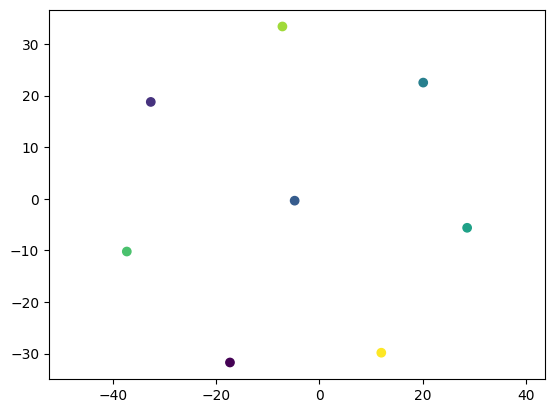

In [40]:
# Create scatter plot of t-SNE results
plt.scatter(points_tsne[:, 0], points_tsne[:, 1], c=labels)
plt.axis("equal")
plt.show()

# Embedding + TSNE

The project can be extended to work with:

- Text Embeddings: Word2Vec, GloVe, or transformer-based embeddings
- Image Embeddings: CNN feature vectors
- Custom Feature Vectors: Domain-specific high-dimensional representations
- Real Datasets: Applying t-SNE to actual news categories or other classification tasks

Tips for Better Results

- Preprocessing: Normalize or standardize your data before applying t-SNE
- Perplexity Tuning: Experiment with different perplexity values (5-50)
- Multiple Runs: Run t-SNE multiple times with different random seeds
- Iteration Count: Increase n_iter for better convergence (default: 1000)
- Early Exaggeration: Adjust early_exaggeration parameter for cluster separation

In [41]:
from sentence_transformers import SentenceTransformer

In [46]:
# Test sentences with different meanings
sentences = [
    "The cat sits on the mat",      # Similar meaning
    "A feline rests on the carpet", # Similar meaning
    "The dog runs in the park",     # Different meaning
    "Mathematics is challenging"     # Completely different
]

colors = ['red', 'blue', 'green', 'orange']

# Load sentence transformer model
embedding = SentenceTransformer('all-MiniLM-L6-v2')

# Get embeddings
vectors = embedding.encode(sentences)

### Expected Similarity Results:

1. Sentence 1 vs 1: ~1.0 (identical)
2. Sentence 1 vs 2: ~0.56 (similar meaning)
3. Sentence 1 vs 3: ~0.09 (different meaning)
4. Sentence 1 vs 4: ~-0.06 (completely different)

In [47]:
# Calculate cosine similarities
query = sentences[0]  # "The cat sits on the mat"
query_embedding = embedding.encode([query])
doc_embeddings = embedding.encode(sentences)
similarities = np.dot(query_embedding, doc_embeddings.T)[0]
similarities

array([ 1.        ,  0.56118834,  0.09489872, -0.0692752 ], dtype=float32)

## Visualization Results
The t-SNE plot shows:

- Red/Blue points (similar sentences) clustered closer together
- Green/Orange points (different meanings) positioned farther apart
- Semantic relationships preserved in 2D space despite 384→2 dimension reduction

(58.11445617675781, 91.41506958007812, -58.32544441223145, -24.496088790893555)

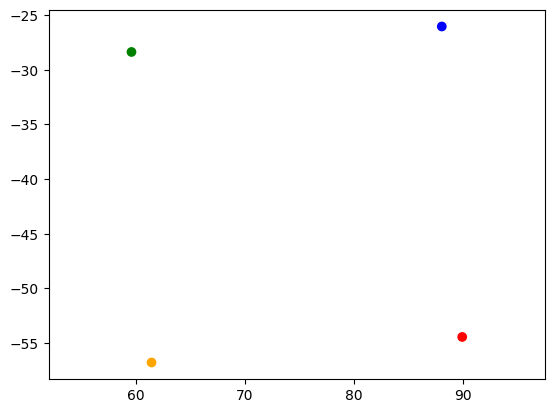

In [48]:
# Apply t-SNE dimensionality reduction
tsne = TSNE(2, random_state=42, perplexity=len(vectors) - 1)
points_tsne = tsne.fit_transform(vectors)

# Create colored scatter plot
plt.scatter(points_tsne[:, 0], points_tsne[:, 1], c=colors)
plt.axis("equal")

# TSNE + Embedding in Real World Application

- Uses sentence transformer to encode news titles
- Converts text to 384-dimensional vectors
- Input: Indonesian news article titles
- Output: Dense numerical representations

In [14]:
sample_data = 1000
df_processed = df.head(sample_data).reset_index().copy()
vecs = embedding.encode(df.Title.head(sample_data).values)
df_vectors = df_processed.merge(pd.DataFrame(vecs).reset_index(), on="index")
df_vectors.head()

,index,Title,Category,Color,0,1,2,3,4,5,...,374,375,376,377,378,379,380,381,382,383
0,2,mengenal swing block dalam bola voli,bola,red,-0.067803,0.128594,-0.001831,-0.033265,-0.030635,0.071402,...,0.028997,0.128950,0.104047,-0.000937,-0.055036,0.018474,0.053562,0.003978,-0.014452,0.060325
1,10,"pendapatan merosot, ini strategi garuda indone...",money,green,0.000364,0.091626,-0.043621,-0.052332,-0.107905,0.043792,...,0.067770,-0.012246,-0.006480,-0.005564,-0.035620,-0.007537,0.143772,0.063047,-0.020332,0.000690
2,11,ini jadwal lengkap rights issue bri,money,green,-0.150944,0.077647,-0.059401,-0.018456,-0.083076,0.014746,...,0.034454,-0.000893,0.014315,-0.012886,-0.037247,-0.042899,0.075888,-0.018928,-0.042208,-0.058062
3,15,"pendapatan merosot, ini strategi garuda indone...",money,green,-0.003584,0.023827,-0.049792,0.011643,-0.078288,0.008061,...,0.002593,0.024816,0.022437,0.035383,-0.088470,-0.008698,0.007418,-0.066796,-0.031306,0.006166
4,16,ini jadwal lengkap rights issue bri,money,green,-0.017050,0.070321,-0.040328,-0.031144,-0.056657,0.006353,...,-0.066577,0.013150,0.002167,-0.020696,0.082093,-0.019934,-0.012420,-0.043887,-0.025750,0.001071


In [50]:
color_mapping = {
    "bola": "red",      # Sports articles
    "money": "green",   # Financial articles
    "sains": "blue"     # Science articles
}

In [51]:
tsne = TSNE(2, random_state=42) # Reduces 384-dimensional sentence embeddings to 2D coordinates
points_tsne = tsne.fit_transform(df_vectors.iloc[:, 4:])

## Visual Clustering Patterns:

- Red dots (Sports/Bola): Scattered throughout but show some clustering
- Green dots (Money/Finance): Form distinct clusters, especially in upper and - lower regions
- Blue dots (Science/Sains): Mixed distribution with some grouping tendencies

### Key Insights:

- Semantic clustering is visible - articles of the same category tend to group together
- Some category overlap - indicates shared vocabulary or multi-topic articles
- Clear separation zones - distinct regions dominated by specific categories
- Successful dimensionality reduction - 384D vectors meaningfully projected to 2D space

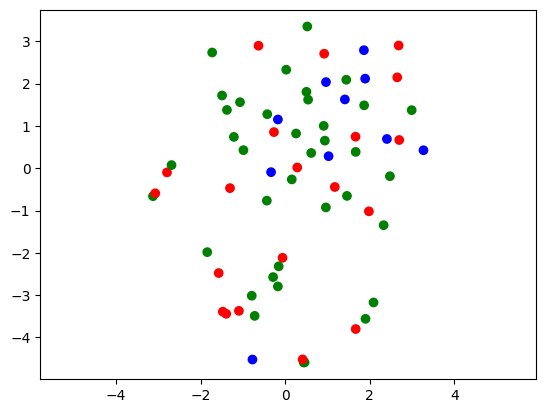

In [16]:
plt.scatter(points_tsne[:, 0], points_tsne[:, 1], c=df_vectors["Color"])
plt.axis("equal");

# Word Visualization

This project demonstrates how to:

1. Train Word2Vec model on Indonesian news text
2. Extract word embeddings from the trained model
3. Apply t-SNE visualization to word vectors
4. Create labeled scatter plots showing semantic word clusters

In [17]:
!pip install gensim

In [18]:
from gensim.models import Word2Vec
import numpy as np
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from string import punctuation
import nltk
nltk.download('stopwords')
sw_indo = stopwords.words("indonesian") + list(punctuation)
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

##### Model Parameters:

1. Vector Size: 100 dimensions per word
2. Window: 5 words context on each side
3. Min Count: Words must appear at least 3 times
4. Workers: 4 parallel threads
5. Epochs: 1000 training iterations

In [21]:
sentences = [word_tokenize(rev.lower()) for rev in df.Title.values]
model = Word2Vec(sentences=sentences, vector_size=128, window=5, min_count=3, workers=4, epochs=1000)
w2v = model.wv

In [32]:
embeddings = []
words = []
for word in w2v.key_to_index.keys():
  words.append(word)
  embeddings.append(w2v[word])
embeddings = np.array(embeddings)

## Visualization Results

### Word Clustering Patterns
The t-SNE plot reveals several semantic clusters:
Sports Cluster:

- "milan", "chelsea", "wolves" (football teams)
- "lawan", "pelatih" (opponent, coach)
- Sports-related terminology grouped together

###General Vocabulary:

- "kartu" (card), "merah" (red) - color/object associations
- "rekening" (account), "belum" (not yet) - financial/temporal terms
- "laga" (match), "klasemen" (standings) - competition terms

### Geographic/Proper Nouns:

- "liverpool", "city" (football clubs)
- "persiraja", "persib" (Indonesian football clubs)
- Location and team names clustering

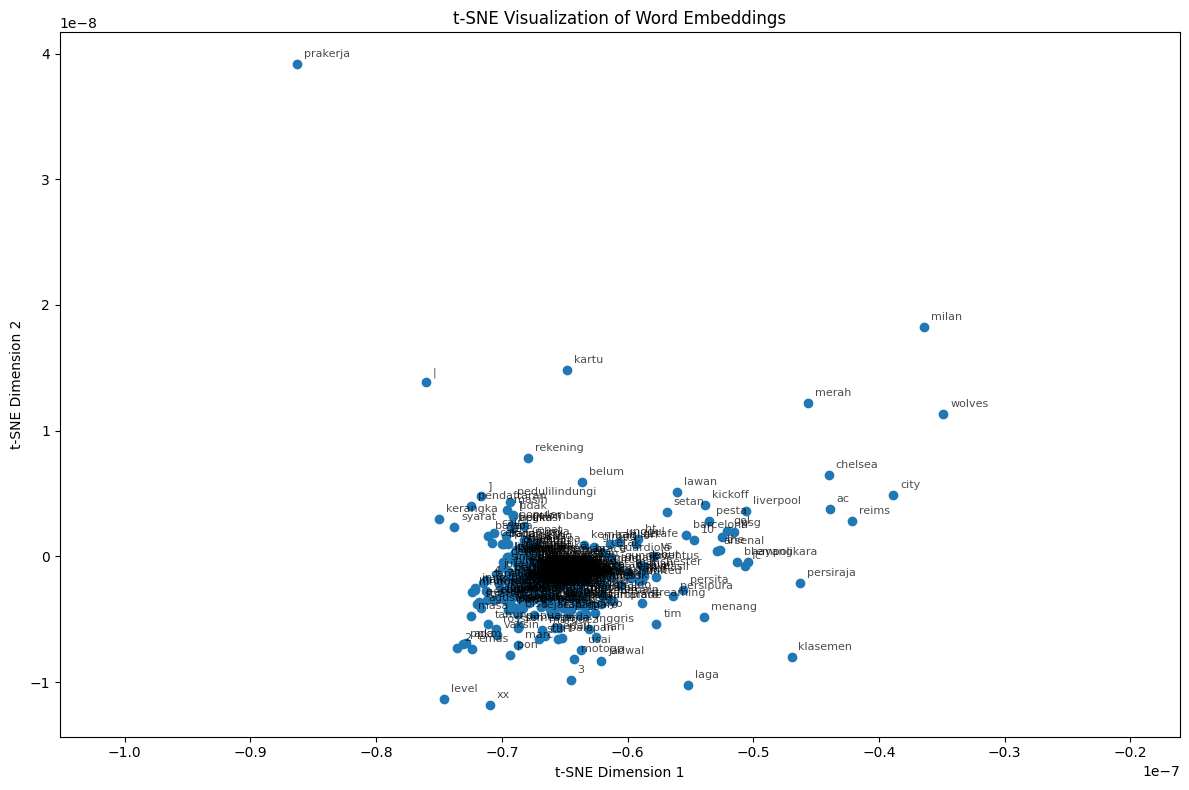

In [35]:
# Create scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(points_tsne[:, 0], points_tsne[:, 1])

# Add word labels to each point
for i, word in enumerate(words):
    plt.annotate(word, (points_tsne[i, 0], points_tsne[i, 1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.7)

plt.axis("equal")
plt.title("t-SNE Visualization of Word Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()